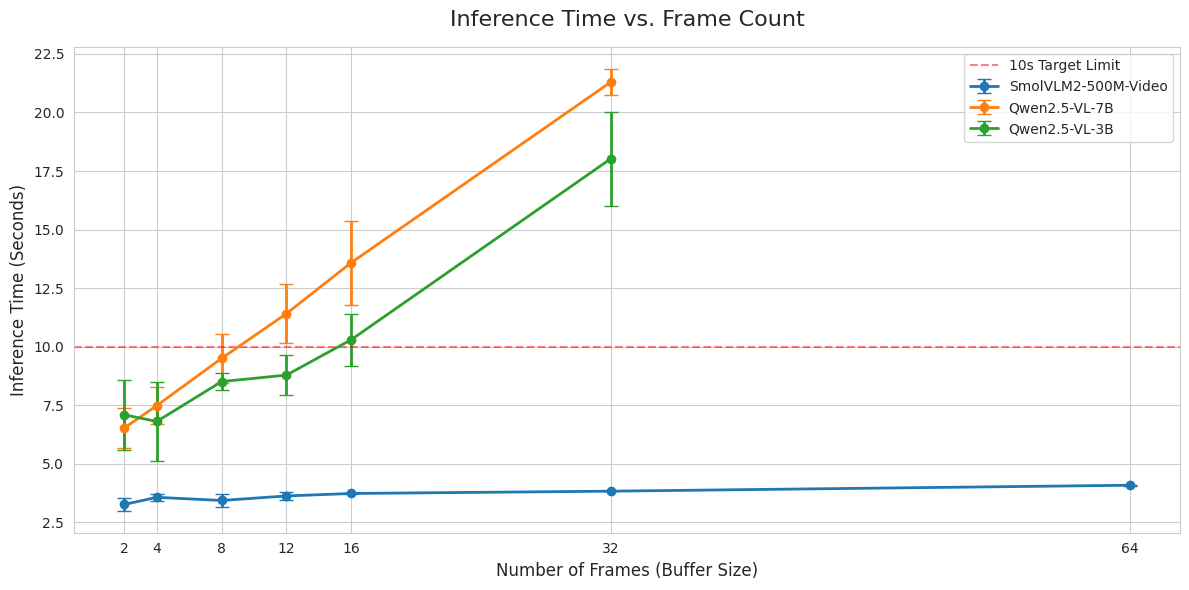


Summary Table (Time in Seconds):
Model   Qwen2.5-VL-3B  Qwen2.5-VL-7B  SmolVLM2-500M-Video
Frames                                                   
2                7.09           6.53                 3.26
4                6.81           7.48                 3.57
8                8.51           9.50                 3.43
12               8.79          11.41                 3.63
16              10.30          13.59                 3.73
32              18.03          21.30                 3.83
64                NaN            NaN                 4.08


In [4]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load the Benchmark Data
file_path = "../../benchmarks/combined_benchmark.json"

with open(file_path, "r") as f:
    data = json.load(f)

# 2. Parse Data into a DataFrame
records = []

for model_name, benchmarks in data.items():
    # Clean up the model name for a cleaner legend (e.g., remove 'unsloth/' and 'bnb-4bit')
    short_name = model_name.split("/")[-1].replace("-bnb-4bit", "").replace("-Instruct", "")
    
    for b in benchmarks:
        records.append({
            "Model": short_name,
            "Frames": b["buffer_size"],
            "Time (s)": b["mean_time"],
            "Std Dev": b["std_time"],
            "FPS": b["mean_fps"]
        })

df = pd.DataFrame(records)

# 3. Plot Inference Time
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Create a color palette
models = df["Model"].unique()
colors = plt.cm.tab10(range(len(models)))

for i, model in enumerate(models):
    subset = df[df["Model"] == model].sort_values("Frames")
    
    plt.errorbar(
        subset["Frames"], 
        subset["Time (s)"], 
        yerr=subset["Std Dev"], 
        label=model, 
        marker='o', 
        linewidth=2,
        capsize=5,
        color=colors[i]
    )

# Formatting
plt.title("Inference Time vs. Frame Count", fontsize=16, pad=15)
plt.xlabel("Number of Frames (Buffer Size)", fontsize=12)
plt.ylabel("Inference Time (Seconds)", fontsize=12)
plt.legend(title="Model", fontsize=10, title_fontsize=12)
plt.xticks(sorted(df["Frames"].unique()))  # Ensure all frame counts are shown on X-axis

# Add a specific line for your 10-second target if you want
plt.axhline(y=10, color='r', linestyle='--', alpha=0.5, label="10s Target Limit")
plt.legend()

plt.tight_layout()
plt.show()

# --- OPTIONAL: Print a quick summary table ---
print("\nSummary Table (Time in Seconds):")
pivot_df = df.pivot(index="Frames", columns="Model", values="Time (s)")
print(pivot_df.round(2))